In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
url = "https://media.githubusercontent.com/media/suhani-pandey/Assignment1_SocialDataAnalysis/refs/heads/main/SF_Crime_Merged_FINAL_CLEAN_2003_2026.csv"
df = pd.read_csv(url, low_memory=False)
print(df.shape)


(2906890, 22)


In [12]:
# Normalize categories fully
df["cat_clean"] = (
    df["Incident Category"]
    .astype(str)
    .str.upper()
    .str.replace("/", " ", regex=False)
    .str.replace("  ", " ", regex=False)
    .str.strip()
)

focus_crimes = [
    "ASSAULT",
    "BURGLARY",
    "LARCENY THEFT",
    "MOTOR VEHICLE THEFT",
    "ROBBERY"
]



yearly = (
    df[df["cat_clean"].isin(focus_crimes)]
    .groupby(["year", "cat_clean"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

print("Years in plot:", yearly.index.min(), "-", yearly.index.max())



Years in plot: 2003 - 2026


## Assignment 1.1: Temporal Overview

Let's start by getting the big picture of how crime has changed over the full 20+ year period covered by your combined dataset.

*Draws from*: Week 1, Exercises 4.1 and 4.2 — applied here to the full merged dataset (2003–present) rather than just 2018–present.

> * Using your combined dataset (2003–present), plot the total number of incidents **per year** for each of your Personal Focus Crimes. Display at least the years 2003–2025. 
> * Make sure your plot follows good visualization practices: labeled axes, a legend, a descriptive title.
> * Identify and comment on at least two notable features in the plot — for example, long-term trends, sudden drops or spikes, or the impact of COVID-19 in 2020. For each feature, offer a possible explanation.

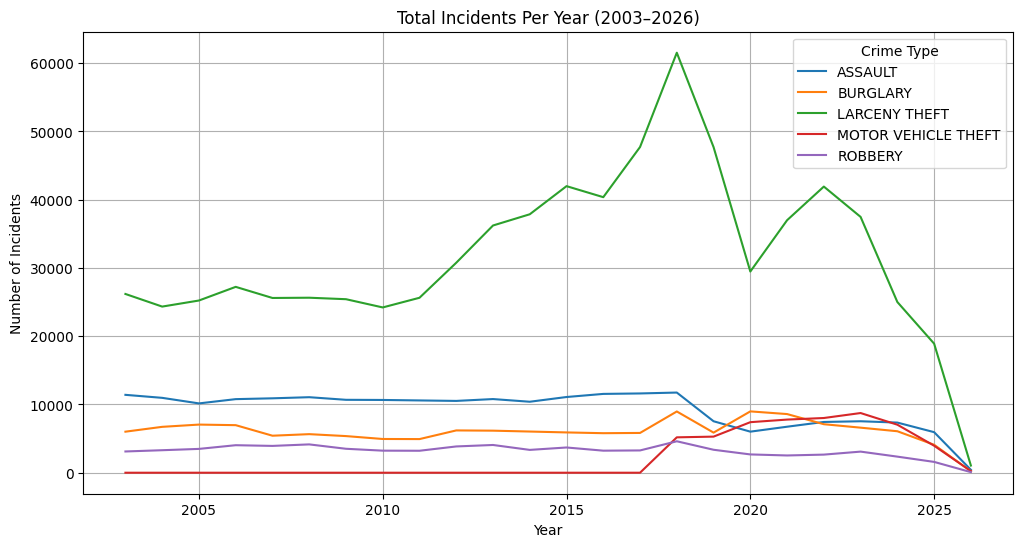

In [ ]:

yearly.plot(figsize=(12,6))
plt.title("Total Incidents Per Year (2003–2026)")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.legend(title="Crime Type")
plt.grid(True)
plt.show()

#Excerise 1.1
The temporal trends from 2003 to 2025 reveal several important patterns across the selected focus crimes.
LONG-TERM TREND IN LARCENY THEFT ::
Larceny Theft is consistently the most frequent crime category throughout the entire period.It increases steadily from the early 2010s and peaks dramatically around 2017-2018,reaching over 60,000 incidents.After this peak,it declines sharply in 2020 before partially recovering and then decreasing again in recent years.The continued decline after 2023 may reflect changes in policing ,reporting practices ,or incomplete data for the most recent years.

COVID-19 IMPACT IN 2020::
Nearly all crime categories show a noticeable drop in 2020.This is especially visible in Larceny Theft and Assault.The timing strongly suggests the impact of the COVID-19 pandemic,when lockdown measures reduced public movement and social interaction.With fewer people in public spaces, opportunities for theft,robbery, and interpersonal conflict decreased.This supports the idea that crime rates are closely linked to routine activities and population mobility.

MOTOR VEHICLE THEFT INCREASE AFTER 2018::
Motor Vechicle Theft increases significantly after 2018 compared to earlier years.This may reflect changing criminal patterns, increased vehicle ownership, or economic pressures influencing property-related crimes. 

---
## Assignment 1.2: Crime Profiles by Police District

Different parts of the city have very different crime patterns. Here we quantify that using conditional probabilities.

*Draws from*: Week 3, Exercises 2.1 and 2.2.

> * For each police district in your dataset, compute the **conditional crime profile**: for each of your Personal Focus Crimes, calculate
>
>   $$r(\text{crime}, \text{district}) = \frac{P(\text{crime} \mid \text{district})}{P(\text{crime})}$$
>
>   A value above 1 means that crime type is *over-represented* in that district relative to the city-wide average; below 1 means it is *under-represented*.
> * Visualize these ratios in a way that makes it easy to compare across both districts and crime types. (Simple barcharts are fine, but you may also use ideas from more complex visualization techniques, for example, a heatmap could work well here, but you're free to choose another format if you can justify it.)
> * Pick **one district** whose profile stands out to you. Describe the pattern and offer an explanation for why that district looks the way it does. Are there geographic, demographic, or other factors that might explain it?

In [4]:
# P(crime)
P_crime = (
    df[df["cat_clean"].isin(focus_crimes)]
    ["cat_clean"]
    .value_counts(normalize=True)
)

print(P_crime)

cat_clean
LARCENY THEFT          0.604844
ASSAULT                0.177152
BURGLARY               0.115121
ROBBERY                0.060429
MOTOR VEHICLE THEFT    0.042455
Name: proportion, dtype: float64


In [31]:
df["Police District"] = df["Police District"].str.upper()
P_crime_given_dist = (
    df[df["cat_clean"].isin(focus_crimes)]
   
    .groupby(["Police District", "cat_clean"])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
)
 

In [32]:

ratio = (P_crime_given_dist / P_crime).unstack()

ratio_focus = ratio[focus_crimes]

ratio_focus.head()

,cat_clean,ASSAULT,BURGLARY,LARCENY THEFT,MOTOR VEHICLE THEFT,ROBBERY
Police District,Police District,,,,,
BAYVIEW,BAYVIEW,1.448144,1.178118,0.719765,2.104183,1.376067
CENTRAL,CENTRAL,0.680751,0.869045,1.177828,0.527066,0.737730
INGLESIDE,INGLESIDE,1.288362,1.220803,0.758620,1.934897,1.493191
MISSION,MISSION,1.305382,0.956565,0.874533,1.109938,1.366075
NORTHERN,NORTHERN,0.723242,1.037951,1.119706,0.698557,0.752657


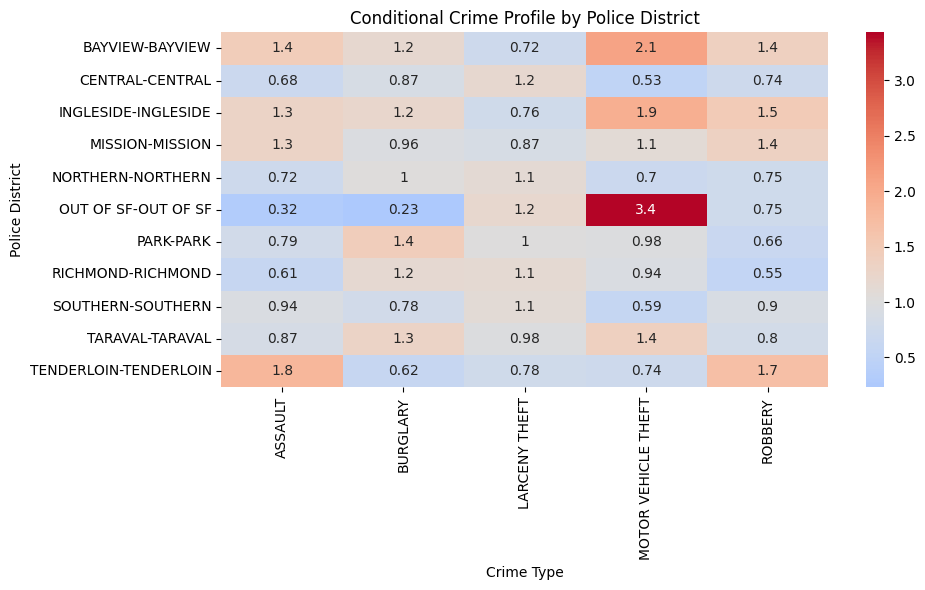

In [33]:
plt.figure(figsize=(10,6))

sns.heatmap(ratio, annot=True, cmap='coolwarm', center=1)

plt.title("Conditional Crime Profile by Police District")
plt.xlabel("Crime Type")
plt.ylabel("Police District")
plt.tight_layout()
plt.show()


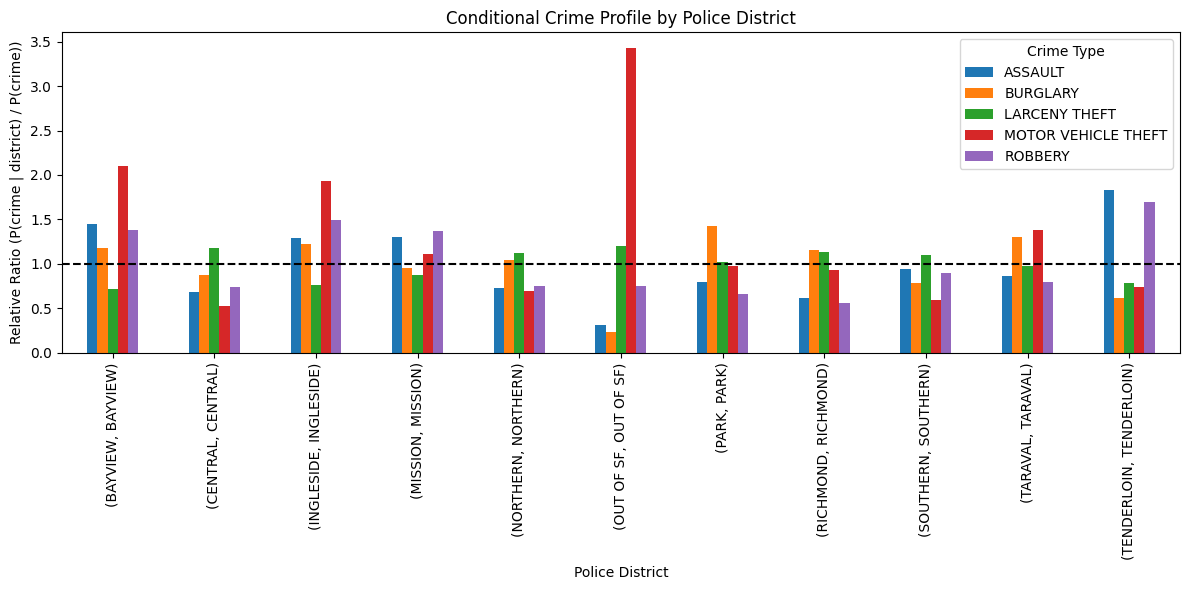

In [ ]:



ratio.plot(kind='bar', figsize=(12,6))

plt.title("Conditional Crime Profile by Police District")
plt.xlabel("Police District")
plt.ylabel("Relative Ratio (P(crime | district) / P(crime))")
plt.axhline(1, color='black', linestyle='--')  # baseline
plt.legend(title="Crime Type")
plt.tight_layout()
plt.show()


Excerise 1.2:CRIME PROFILE BY POLICE DISTRICT
DISTRICT THAT STANDS OUT::TENDERLOIN
The tenderloin district stands out clearly in the conditional crime profile.
From the heatmap:
.Assault(1.8) is substantially over-represented
.Robbery(1.7) is also clearly over-represented
.Burglary(0.62) is under-represented
.Motor Vehicle Theft(0.74) is below the city average
.Larceny Theft(0.78) is slightly under-represented

INTERPRETATION::
The over-representation of assault and robbery in the Tenderloin likely reflects the district's unique social and geographic characteristics.The Tenderloin is a densely populated urban area with high pedestrain traffic, significant commerical activity, and active nightlife.Such environments increase opportunities for interpersonal interaction,which can elevate the likelihood of violent offenses.
Additionally,the district has long been associated with socioeconomic challenges,including higher levels of poverty and homelessness.These structural factors may contribute to elevated rates of certain types of violent crime.
In contrast,burglary and motor vehicle theft are under-represented relative to the city average.Thid suggests that property crimes involving residences or vehicles may be more prevalent in districts with more residential density or greater vehicle ownership, rather than in highly centralized urban areas like the Tenderloin.

The conditional crime profile demonstrates that crime composition varies substantially across police districts.The Tenderloin exhibits a distinct pattern characterized by over-representation of violent crimes and under-representation of certain property crimes.This highlights the importance of geographic and social context when analyzing urban crime patterns and shows that crime is not evenly distributed across space.